In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import xgboost as xgb

# Set plotting theme
sns.set_theme(style="whitegrid")

# Dynamically locate the project root directory
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "processed_features.parquet"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"❌ Could not find processed features at: {DATA_PATH.resolve()}\n"
        f"Please ensure you've executed your ingestion/cleansing scripts first!"
    )

print(f"📖 Loading engineered feature matrix from: {DATA_PATH.name}...")
df = pd.read_parquet(DATA_PATH)
print(f"📊 Matrix loaded. Shape: {df.shape[0]:,} rows, {df.shape[1]} columns.")
df.head()

📖 Loading engineered feature matrix from: processed_features.parquet...
📊 Matrix loaded. Shape: 283,726 rows, 31 columns.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.774718,-1.996823,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.268530,-1.996823,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.959811,-1.996802,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.411487,-1.996802,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.667362,-1.996781,0


In [2]:
# Separate features from target label matrix
X = df.drop(columns=['Class'])
y = df['Class']

# Execute a Stratified Split. This is non-negotiable for extreme class imbalances 
# to ensure the training and test sets perfectly mirror the original target distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✂️ Stratified Splitting Lineage Results:")
print(f" - Train Set Matrix: {X_train.shape[0]:,} samples | Fraud Cases: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f" - Test Set Matrix:  {X_test.shape[0]:,} samples | Fraud Cases: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

✂️ Stratified Splitting Lineage Results:
 - Train Set Matrix: 226,980 samples | Fraud Cases: 378 (0.1665%)
 - Test Set Matrix:  56,746 samples | Fraud Cases: 95 (0.1674%)


In [3]:
# Calculate the exact empirical balancing scale factor for XGBoost
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_weight = neg_count / pos_count

print("⚖️ Imbalance Optimization Math:")
print(f" - Negative Instances (Legit): {neg_count:,}")
print(f" - Positive Instances (Fraud): {pos_count:,}")
print(f" - Calculated 'scale_pos_weight' factor: {scale_weight:.4f}")
print("\nDomain Note: This penalty multiplier forces the loss function to penalize a missed "
      "fraudulent transaction heavily, countering the major class skewness.")

⚖️ Imbalance Optimization Math:
 - Negative Instances (Legit): 226,602
 - Positive Instances (Fraud): 378
 - Calculated 'scale_pos_weight' factor: 599.4762

Domain Note: This penalty multiplier forces the loss function to penalize a missed fraudulent transaction heavily, countering the major class skewness.


In [4]:
print("🏋️ Initializing and Training Baseline XGBoost Classifier Engine...")

# Configure baseline model hyperparameters
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",  # Area Under Precision-Recall is optimal for highly imbalanced fraud tasks
    scale_pos_weight=scale_weight,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)

# Fit model
xgb_model.fit(X_train, y_train)
print("✅ Training complete. Baseline weights locked.")

🏋️ Initializing and Training Baseline XGBoost Classifier Engine...
✅ Training complete. Baseline weights locked.


📊 Classification Performance Report:
              precision    recall  f1-score   support

 Genuine (0)       1.00      1.00      1.00     56651
   Fraud (1)       0.59      0.80      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



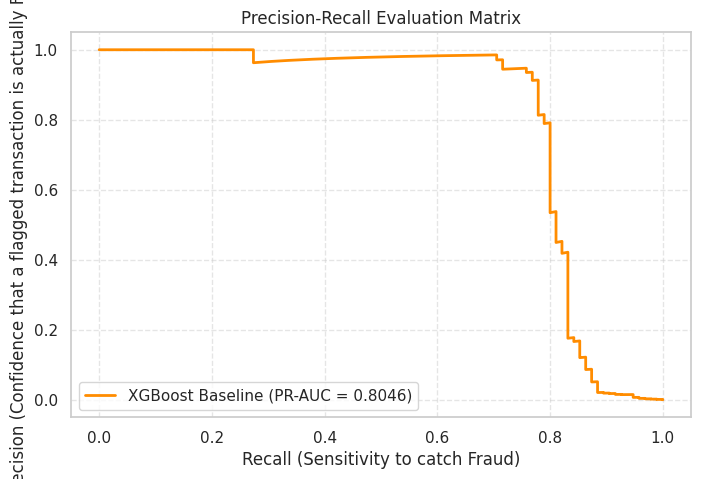

In [5]:
# Generate prediction states and probability matrices
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("📊 Classification Performance Report:")
print(classification_report(y_test, y_pred, target_names=["Genuine (0)", "Fraud (1)"]))

# Generate the Precision-Recall curve vectors
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Plot Precision-Recall Curve (The golden governance standard for fraud evaluation)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'XGBoost Baseline (PR-AUC = {pr_auc:.4f})', color='darkorange', lw=2)
plt.xlabel('Recall (Sensitivity to catch Fraud)')
plt.ylabel('Precision (Confidence that a flagged transaction is actually Fraud)')
plt.title('Precision-Recall Evaluation Matrix')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()